<a href="https://colab.research.google.com/github/subod4/ADdetection/blob/main/nepali_currency_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nepali Currency Note Detection and Classification

This notebook implements a deep learning model to detect and classify Nepali currency notes into different denominations:
- Five (Rs. 5)
- Ten (Rs. 10)
- Twenty (Rs. 20)
- Fifty (Rs. 50)
- Hundred (Rs. 100)
- Five Hundred (Rs. 500)
- Thousand (Rs. 1000)

We'll use:
1. **OCR (Optical Character Recognition)** for text detection on currency
2. **CNN with Transfer Learning** for currency classification

## 1. Import Required Libraries

In [10]:
# Install required packages (run once)
!pip install tensorflow opencv-python matplotlib numpy pandas scikit-learn pillow easyocr seaborn -q

In [11]:
# Import libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50V2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Scikit-learn imports
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# OCR import
import easyocr

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load and Explore Dataset

In [12]:
# Define dataset paths
BASE_DIR = r"/content"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR = os.path.join(BASE_DIR, "test")

# Currency classes (denominations)
CLASSES = ['five', 'ten', 'twenty', 'fifty', 'hundred', 'fivehundred', 'thousand']
NUM_CLASSES = len(CLASSES)

# Class labels mapping
class_labels = {
    'five': 'Rs. 5',
    'ten': 'Rs. 10',
    'twenty': 'Rs. 20',
    'fifty': 'Rs. 50',
    'hundred': 'Rs. 100',
    'fivehundred': 'Rs. 500',
    'thousand': 'Rs. 1000'
}

print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {CLASSES}")

Number of classes: 7
Classes: ['five', 'ten', 'twenty', 'fifty', 'hundred', 'fivehundred', 'thousand']


In [13]:
# Count images in each class
def count_images(directory):
    """Count images in each class folder"""
    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))])
            class_counts[class_name] = count
    return class_counts

# Count images in train, valid, test sets
train_counts = count_images(TRAIN_DIR)
valid_counts = count_images(VALID_DIR)
test_counts = count_images(TEST_DIR)

# Display counts
print("=" * 50)
print("Dataset Distribution:")
print("=" * 50)
print(f"\n{'Class':<15} {'Train':<10} {'Valid':<10} {'Test':<10}")
print("-" * 45)
for cls in CLASSES:
    train_c = train_counts.get(cls, 0)
    valid_c = valid_counts.get(cls, 0)
    test_c = test_counts.get(cls, 0)
    print(f"{cls:<15} {train_c:<10} {valid_c:<10} {test_c:<10}")
print("-" * 45)
print(f"{'Total':<15} {sum(train_counts.values()):<10} {sum(valid_counts.values()):<10} {sum(test_counts.values()):<10}")

Dataset Distribution:

Class           Train      Valid      Test      
---------------------------------------------
five            1500       500        130       
ten             1500       500        513       
twenty          1500       500        485       
fifty           1500       500        149       
hundred         1500       500        661       
fivehundred     1500       500        151       
thousand        1500       500        160       
---------------------------------------------
Total           10500      3500       2249      


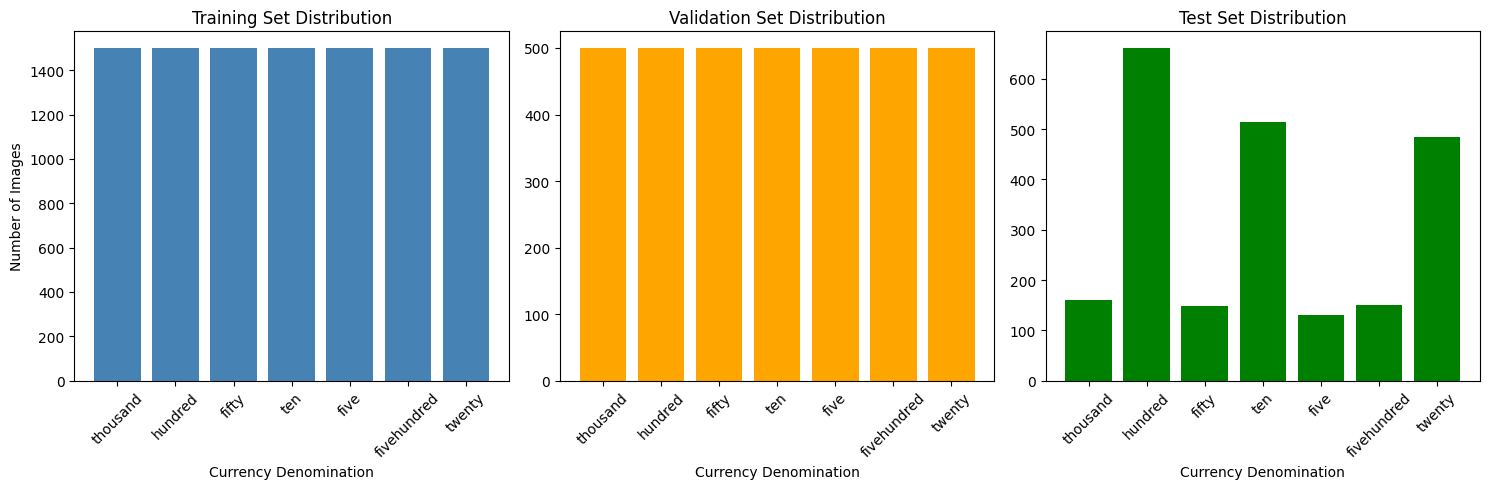

In [14]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Train distribution
axes[0].bar(train_counts.keys(), train_counts.values(), color='steelblue')
axes[0].set_title('Training Set Distribution', fontsize=12)
axes[0].set_xlabel('Currency Denomination')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)

# Validation distribution
axes[1].bar(valid_counts.keys(), valid_counts.values(), color='orange')
axes[1].set_title('Validation Set Distribution', fontsize=12)
axes[1].set_xlabel('Currency Denomination')
axes[1].tick_params(axis='x', rotation=45)

# Test distribution
axes[2].bar(test_counts.keys(), test_counts.values(), color='green')
axes[2].set_title('Test Set Distribution', fontsize=12)
axes[2].set_xlabel('Currency Denomination')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Sample images from Training Set:


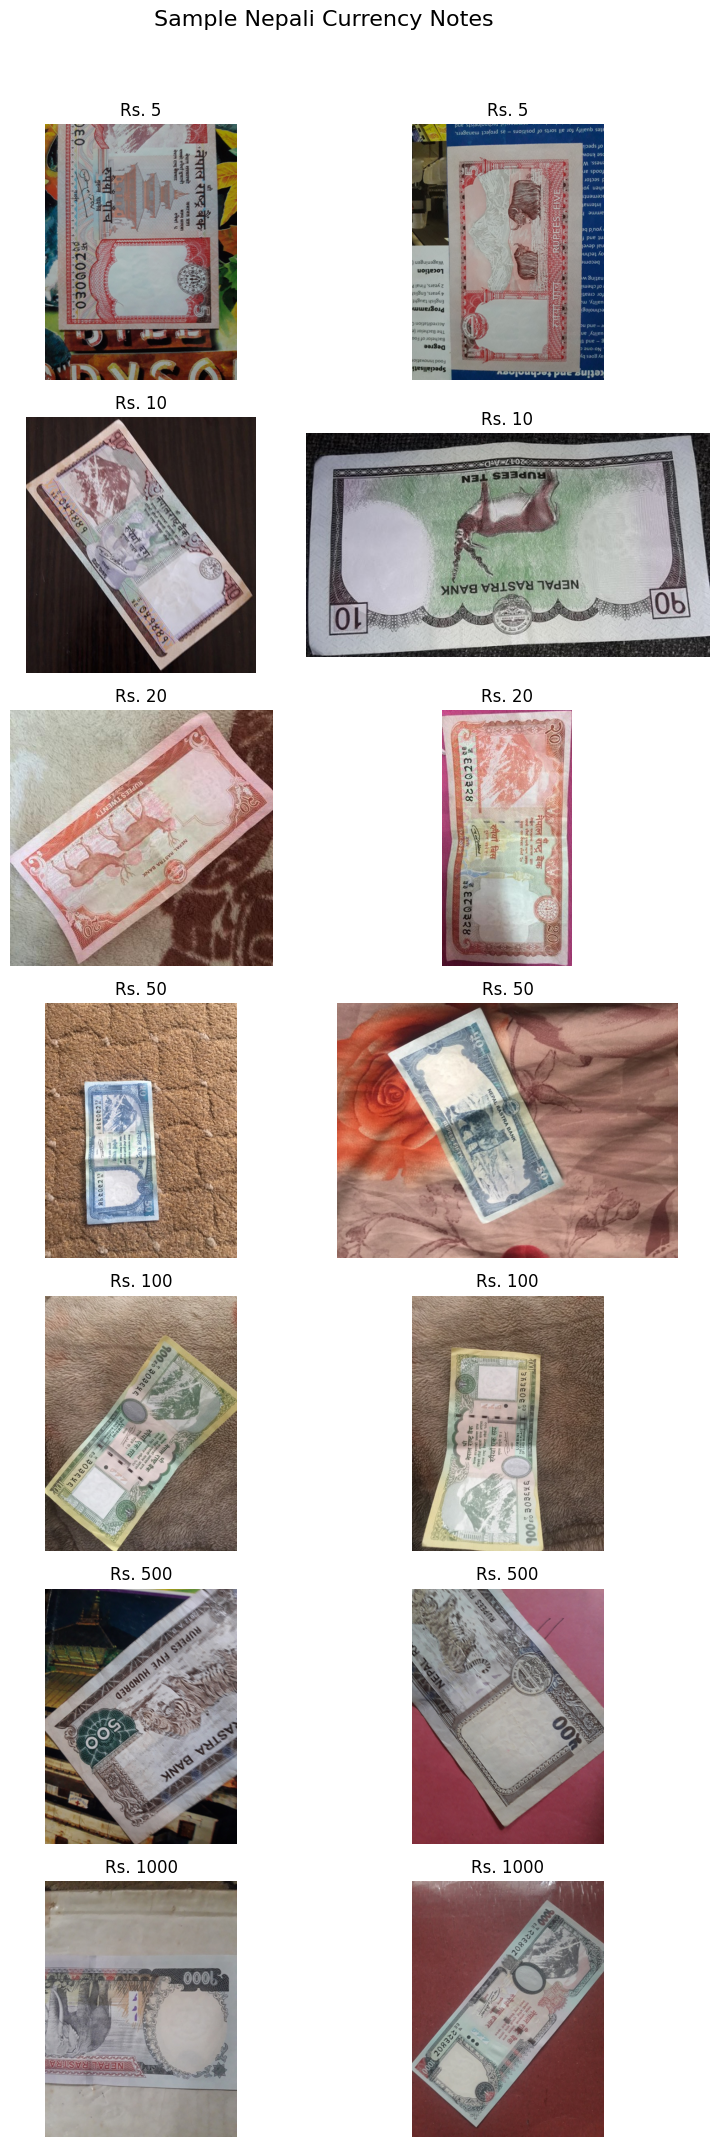

In [15]:
# Display sample images from each class
def display_sample_images(directory, num_samples=2):
    """Display sample images from each class"""
    fig, axes = plt.subplots(len(CLASSES), num_samples, figsize=(4*num_samples, 3*len(CLASSES)))

    for i, class_name in enumerate(CLASSES):
        class_path = os.path.join(directory, class_name)
        if os.path.exists(class_path):
            images = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

            for j in range(min(num_samples, len(images))):
                img_path = os.path.join(class_path, images[j])
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    axes[i, j].imshow(img)
                    axes[i, j].set_title(f'{class_labels.get(class_name, class_name)}')
                    axes[i, j].axis('off')

    plt.suptitle('Sample Nepali Currency Notes', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

print("Sample images from Training Set:")
display_sample_images(TRAIN_DIR, num_samples=2)

## 3. Data Preprocessing and Augmentation

In [16]:
# Image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Only rescaling for validation and test
valid_test_datagen = ImageDataGenerator(rescale=1./255)

print("Data generators created with augmentation for training set")

Data generators created with augmentation for training set


In [17]:
# Create data generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

valid_generator = valid_test_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Display class indices
print("\nClass Indices:", train_generator.class_indices)
print(f"\nTraining samples: {train_generator.samples}")
print(f"Validation samples: {valid_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 10500 images belonging to 7 classes.
Found 3500 images belonging to 7 classes.
Found 2249 images belonging to 7 classes.

Class Indices: {'fifty': 0, 'five': 1, 'fivehundred': 2, 'hundred': 3, 'ten': 4, 'thousand': 5, 'twenty': 6}

Training samples: 10500
Validation samples: 3500
Test samples: 2249


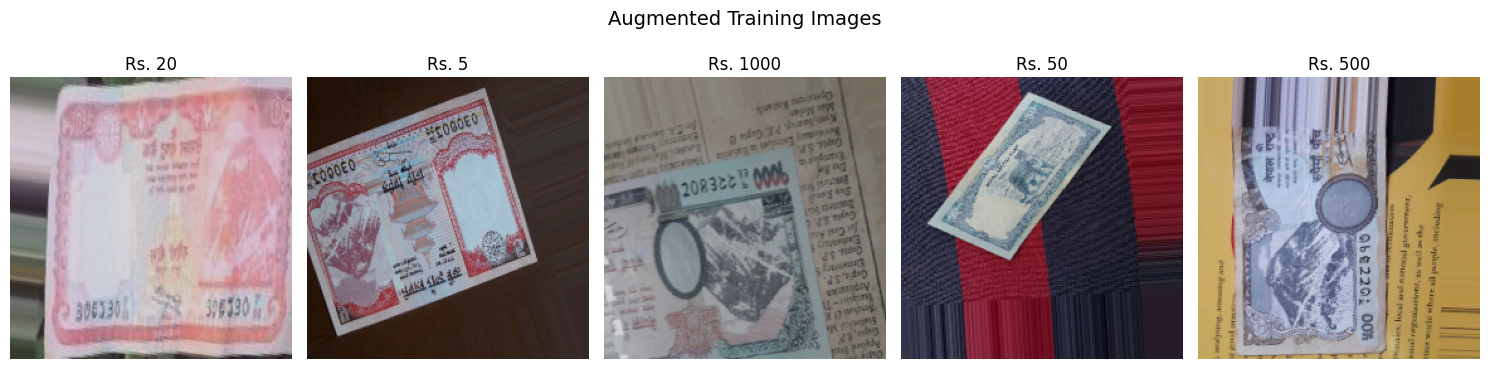

In [18]:
# Visualize augmented images
def visualize_augmentation(generator, num_images=5):
    """Visualize augmented images"""
    fig, axes = plt.subplots(1, num_images, figsize=(15, 4))

    # Get a batch of images
    images, labels = next(generator)

    for i in range(min(num_images, len(images))):
        axes[i].imshow(images[i])
        class_idx = np.argmax(labels[i])
        class_name = list(generator.class_indices.keys())[class_idx]
        axes[i].set_title(f'{class_labels.get(class_name, class_name)}')
        axes[i].axis('off')

    plt.suptitle('Augmented Training Images', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_augmentation(train_generator)

## 4. Build OCR Text Detection Model

We'll use EasyOCR to extract text from currency notes, which can help identify denominations and other features.

In [19]:
# Initialize EasyOCR reader
# Using English and Hindi (Hindi shares similar script with Nepali Devanagari)
reader = easyocr.Reader(['en', 'hi'], gpu=tf.config.list_physical_devices('GPU') != [])
print("EasyOCR reader initialized successfully!")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR reader initialized successfully!


Testing OCR on: /content/train/five/five_train_771.jpg


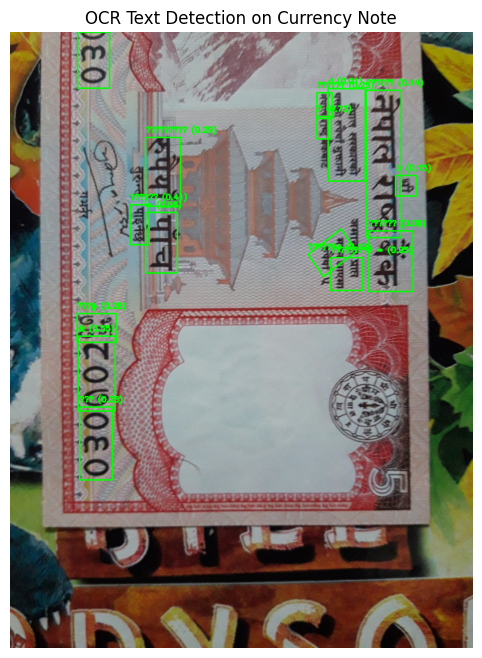


Detected Texts:
  Text: 'ठ' | Confidence: 0.72
  Text: 'तै' | Confidence: 0.25
  Text: '7' | Confidence: 0.73
  Text: 'd' | Confidence: 0.01
  Text: 'डै॰' | Confidence: 0.29
  Text: 'बै' | Confidence: 0.14
  Text: '>' | Confidence: 0.15
  Text: 'डै' | Confidence: 0.41
  Text: '=' | Confidence: 0.05
  Text: 'त्ँ =' | Confidence: 0.05
  Text: 'शः' | Confidence: 0.09
  Text: '६#' | Confidence: 0.28
  Text: '&' | Confidence: 0.55
  Text: 'ठ' | Confidence: 0.26
  Text: 'ई्#' | Confidence: 0.12


In [20]:
def perform_ocr(image_path):
    """
    Perform OCR on currency image to detect text
    Returns detected text and bounding boxes
    """
    # Read image
    img = cv2.imread(image_path)
    if img is None:
        return [], None

    # Perform OCR
    results = reader.readtext(img)

    # Extract text and confidence
    detected_texts = []
    for (bbox, text, confidence) in results:
        detected_texts.append({
            'text': text,
            'confidence': confidence,
            'bbox': bbox
        })

    return detected_texts, img

def visualize_ocr_results(image_path):
    """Visualize OCR detection results on image"""
    detected_texts, img = perform_ocr(image_path)

    if img is None:
        print(f"Could not read image: {image_path}")
        return

    # Draw bounding boxes
    img_with_boxes = img.copy()
    for detection in detected_texts:
        bbox = detection['bbox']
        text = detection['text']
        conf = detection['confidence']

        # Convert bbox to integer coordinates
        pts = np.array(bbox, dtype=np.int32)
        cv2.polylines(img_with_boxes, [pts], True, (0, 255, 0), 2)

        # Put text
        cv2.putText(img_with_boxes, f"{text} ({conf:.2f})",
                   (int(bbox[0][0]), int(bbox[0][1]) - 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Display
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
    plt.title('OCR Text Detection on Currency Note')
    plt.axis('off')
    plt.show()

    # Print detected texts
    print("\nDetected Texts:")
    for det in detected_texts:
        print(f"  Text: '{det['text']}' | Confidence: {det['confidence']:.2f}")

    return detected_texts

# Test OCR on a sample image
sample_class = CLASSES[0]
sample_dir = os.path.join(TRAIN_DIR, sample_class)
if os.path.exists(sample_dir):
    sample_images = os.listdir(sample_dir)
    if sample_images:
        sample_path = os.path.join(sample_dir, sample_images[0])
        print(f"Testing OCR on: {sample_path}")
        visualize_ocr_results(sample_path)

## 5. Build Currency Classification Model

Using Transfer Learning with MobileNetV2 for efficient and accurate classification.

In [21]:
def build_classification_model(num_classes, input_shape=(224, 224, 3)):
    """
    Build a CNN model using Transfer Learning with MobileNetV2
    """
    # Load pre-trained MobileNetV2 (without top layer)
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze base model layers initially
    base_model.trainable = False

    # Build the model
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        BatchNormalization(),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    return model, base_model

# Build model
model, base_model = build_classification_model(NUM_CLASSES)

# Display model summary
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,054,151 (11.65 MB)

 Trainable params: 792,583 (3.02 MB)

 Non-trainable params: 2,261,568 (8.63 MB)

In [22]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


## 6. Train the Models

In [23]:
# Define callbacks
callbacks = [
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Save best model
    ModelCheckpoint(
        filepath=os.path.join(BASE_DIR, 'best_currency_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Reduce learning rate when plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configured successfully!")

Callbacks configured successfully!


In [24]:
# Phase 1: Train with frozen base model
EPOCHS_PHASE1 = 20

print("=" * 60)
print("Phase 1: Training with frozen base model layers")
print("=" * 60)

history_phase1 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    validation_data=valid_generator,
    callbacks=callbacks,
    verbose=1
)

Phase 1: Training with frozen base model layers
Epoch 1/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 0.7081 - loss: 0.8416
Epoch 1: val_accuracy improved from -inf to 0.86886, saving model to /content/best_currency_model.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 257s 723ms/step - accuracy: 0.7085 - loss: 0.8407 - val_accuracy: 0.8689 - val_loss: 0.3983 - learning_rate: 0.0010
Epoch 2/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.9100 - loss: 0.2631
Epoch 2: val_accuracy improved from 0.86886 to 0.87943, saving model to /content/best_currency_model.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 189s 574ms/step - accuracy: 0.9100 - loss: 0.2630 - val_accuracy: 0.8794 - val_loss: 0.4192 - learning_rate: 0.0010
Epoch 3/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.9268 - loss: 0.2103
Epoch 3: val_accuracy improved from 0.87943 to 0.90314, saving model to /content/best_currency_model.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 189s 574ms/step - accuracy: 0.9268 - loss: 0.2102 -

In [25]:
# Phase 2: Fine-tuning - Unfreeze some layers of base model
print("=" * 60)
print("Phase 2: Fine-tuning with unfrozen top layers")
print("=" * 60)

# Unfreeze the top layers of the base model
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print trainable status
print(f"Total layers: {len(base_model.layers)}")
print(f"Trainable layers: {sum([1 for l in base_model.layers if l.trainable])}")

Phase 2: Fine-tuning with unfrozen top layers
Total layers: 154
Trainable layers: 30


In [26]:
# Continue training with fine-tuning
EPOCHS_PHASE2 = 15

history_phase2 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE2,
    validation_data=valid_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.9482 - loss: 0.1723
Epoch 1: val_accuracy did not improve from 0.92829
329/329 ━━━━━━━━━━━━━━━━━━━━ 225s 627ms/step - accuracy: 0.9482 - loss: 0.1722 - val_accuracy: 0.8380 - val_loss: 1.1087 - learning_rate: 1.0000e-04
Epoch 2/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.9821 - loss: 0.0558
Epoch 2: val_accuracy did not improve from 0.92829
329/329 ━━━━━━━━━━━━━━━━━━━━ 192s 582ms/step - accuracy: 0.9821 - loss: 0.0557 - val_accuracy: 0.9069 - val_loss: 0.4990 - learning_rate: 1.0000e-04
Epoch 3/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.9862 - loss: 0.0442
Epoch 3: val_accuracy improved from 0.92829 to 0.94657, saving model to /content/best_currency_model.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 191s 580ms/step - accuracy: 0.9862 - loss: 0.0442 - val_accuracy: 0.9466 - val_loss: 0.2569 - learning_rate: 1.0000e-04
Epoch 4/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.9900 - loss:

In [27]:
# Save the final model
model.save(os.path.join(BASE_DIR, 'nepali_currency_classifier.keras'))
print(f"Model saved to: {os.path.join(BASE_DIR, 'nepali_currency_classifier.keras')}")

Model saved to: /content/nepali_currency_classifier.keras


## 7. Evaluate Model Performance

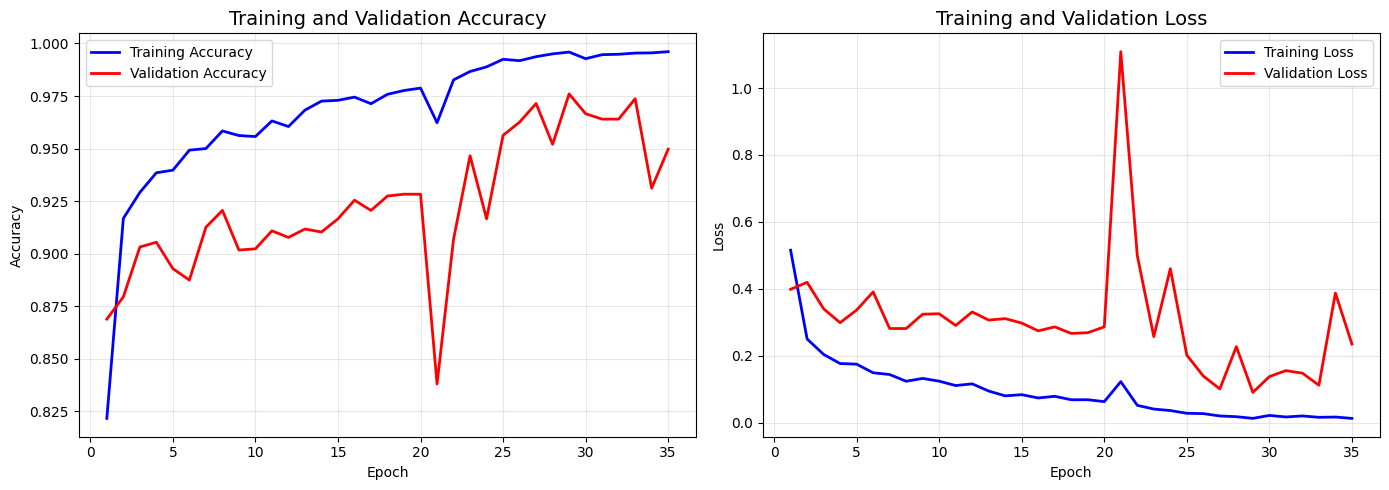

In [28]:
# Plot training history
def plot_training_history(history1, history2=None):
    """Plot training and validation metrics"""

    # Combine histories if phase 2 exists
    if history2:
        acc = history1.history['accuracy'] + history2.history['accuracy']
        val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
        loss = history1.history['loss'] + history2.history['loss']
        val_loss = history1.history['val_loss'] + history2.history['val_loss']
    else:
        acc = history1.history['accuracy']
        val_acc = history1.history['val_accuracy']
        loss = history1.history['loss']
        val_loss = history1.history['val_loss']

    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    axes[0].plot(epochs_range, acc, 'b-', label='Training Accuracy', linewidth=2)
    axes[0].plot(epochs_range, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
    axes[0].set_title('Training and Validation Accuracy', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss plot
    axes[1].plot(epochs_range, loss, 'b-', label='Training Loss', linewidth=2)
    axes[1].plot(epochs_range, val_loss, 'r-', label='Validation Loss', linewidth=2)
    axes[1].set_title('Training and Validation Loss', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot combined training history
plot_training_history(history_phase1, history_phase2)

In [29]:
# Evaluate on test set
print("=" * 60)
print("Evaluation on Test Set")
print("=" * 60)

# Get predictions
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# Get class names
class_names = list(test_generator.class_indices.keys())

# Calculate accuracy
test_accuracy = accuracy_score(true_classes, predicted_classes)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")

Evaluation on Test Set
71/71 ━━━━━━━━━━━━━━━━━━━━ 24s 282ms/step

Test Accuracy: 96.18%


In [30]:
# Classification Report
print("\n" + "=" * 60)
print("Classification Report")
print("=" * 60)
print(classification_report(true_classes, predicted_classes, target_names=class_names))


Classification Report
              precision    recall  f1-score   support

       fifty       0.93      0.99      0.96       149
        five       0.99      1.00      1.00       130
 fivehundred       0.92      1.00      0.96       151
     hundred       1.00      0.89      0.94       661
         ten       0.92      0.99      0.95       513
    thousand       0.94      0.99      0.96       160
      twenty       1.00      0.99      0.99       485

    accuracy                           0.96      2249
   macro avg       0.95      0.98      0.97      2249
weighted avg       0.96      0.96      0.96      2249



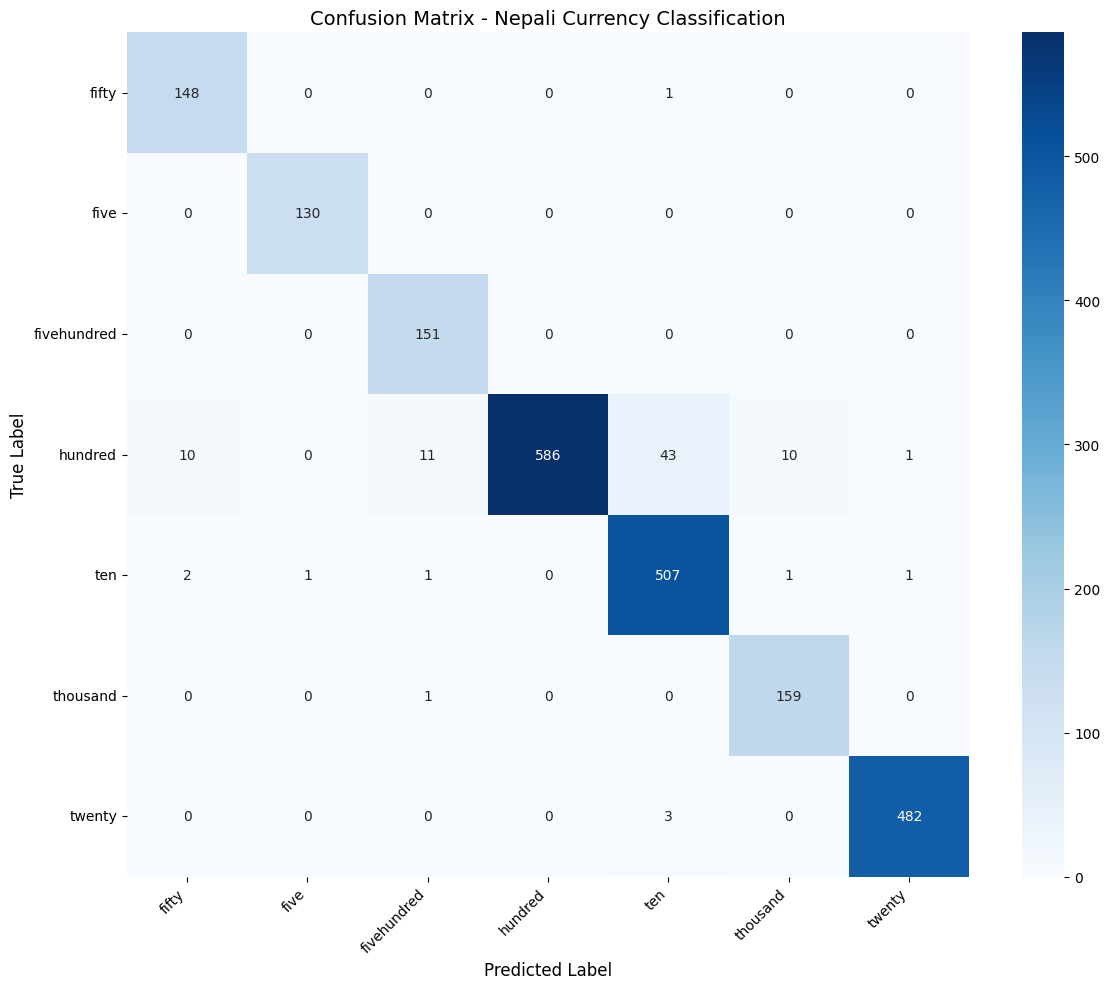

In [31]:
# Confusion Matrix
def plot_confusion_matrix(true_labels, pred_labels, class_names):
    """Plot confusion matrix as a heatmap"""
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Nepali Currency Classification', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return cm

cm = plot_confusion_matrix(true_classes, predicted_classes, class_names)

In [32]:
# Per-class accuracy
print("\n" + "=" * 60)
print("Per-Class Accuracy")
print("=" * 60)
for i, class_name in enumerate(class_names):
    class_mask = true_classes == i
    class_acc = np.mean(predicted_classes[class_mask] == i)
    print(f"{class_labels.get(class_name, class_name)}: {class_acc * 100:.2f}%")


Per-Class Accuracy
Rs. 50: 99.33%
Rs. 5: 100.00%
Rs. 500: 100.00%
Rs. 100: 88.65%
Rs. 10: 98.83%
Rs. 1000: 99.38%
Rs. 20: 99.38%


## 8. Test on Sample Images

Complete pipeline for detecting and classifying Nepali currency notes.

In [33]:
def predict_currency(image_path, model, class_names, show_ocr=True):
    """
    Complete pipeline to detect and classify Nepali currency

    Args:
        image_path: Path to the currency image
        model: Trained classification model
        class_names: List of class names
        show_ocr: Whether to perform OCR detection

    Returns:
        dict: Prediction results with class, confidence, and OCR text
    """
    # Load and preprocess image for classification
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image {image_path}")
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize for model
    img_resized = cv2.resize(img_rgb, (IMG_WIDTH, IMG_HEIGHT))
    img_normalized = img_resized / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)

    # Get prediction
    predictions = model.predict(img_batch, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_idx] * 100
    predicted_class = class_names[predicted_idx]

    # Perform OCR if requested
    ocr_texts = []
    if show_ocr:
        ocr_results, _ = perform_ocr(image_path)
        ocr_texts = [r['text'] for r in ocr_results]

    result = {
        'predicted_class': predicted_class,
        'denomination': class_labels.get(predicted_class, predicted_class),
        'confidence': confidence,
        'all_probabilities': {class_names[i]: predictions[0][i] * 100
                            for i in range(len(class_names))},
        'ocr_texts': ocr_texts
    }

    return result, img_rgb

def visualize_prediction(image_path, model, class_names, show_ocr=True):
    """Visualize prediction with image and details"""
    result, img = predict_currency(image_path, model, class_names, show_ocr)

    if result is None:
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Show image
    axes[0].imshow(img)
    axes[0].set_title(f"Predicted: {result['denomination']}\nConfidence: {result['confidence']:.2f}%",
                     fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Show probability distribution
    probs = result['all_probabilities']
    colors = ['green' if k == result['predicted_class'] else 'steelblue' for k in probs.keys()]

    bars = axes[1].barh(list(probs.keys()), list(probs.values()), color=colors)
    axes[1].set_xlabel('Probability (%)', fontsize=12)
    axes[1].set_title('Classification Probabilities', fontsize=14)
    axes[1].set_xlim(0, 100)

    # Add value labels on bars
    for bar, val in zip(bars, probs.values()):
        axes[1].text(val + 1, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Print OCR results
    if show_ocr and result['ocr_texts']:
        print("\nOCR Detected Texts:")
        for text in result['ocr_texts']:
            print(f"  - {text}")

    return result

Testing on Sample Images from Test Set

True Class: Rs. 5


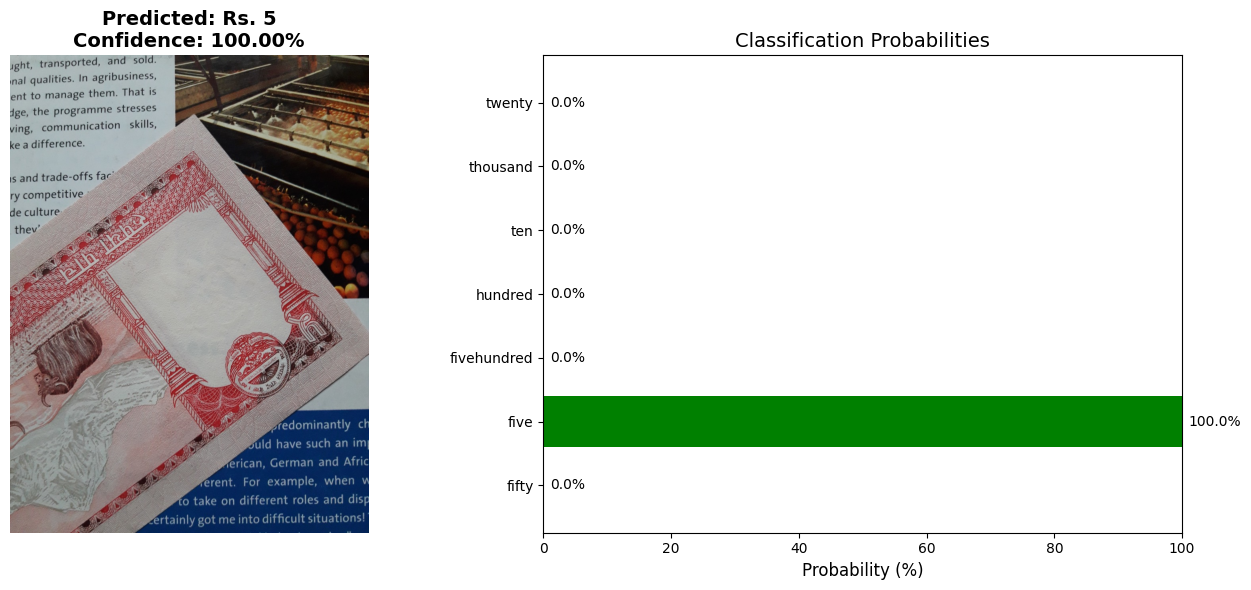


OCR Detected Texts:
  - Ight,   transported,
  - and
  - sold.
  - nal
  - qualities. In agribusiness,
  - ent to manage them. That is
  - dge, the programme stresses
  - communication
  - skills,
  - ke a difference.
  - IS and trade-offs far
  - ry
  - competitive
  - de culture
  - thev
  - redominantly
  - cl
  - Juld have such an im
  - erican, German and Afric
  - erent.
  - For
  - example, when
  - co take on different roles and
  - zertainly
  - me into difficult situations!
  - ving
  - dcene
  - Jesin
  - disp
  - Bot

True Class: Rs. 10


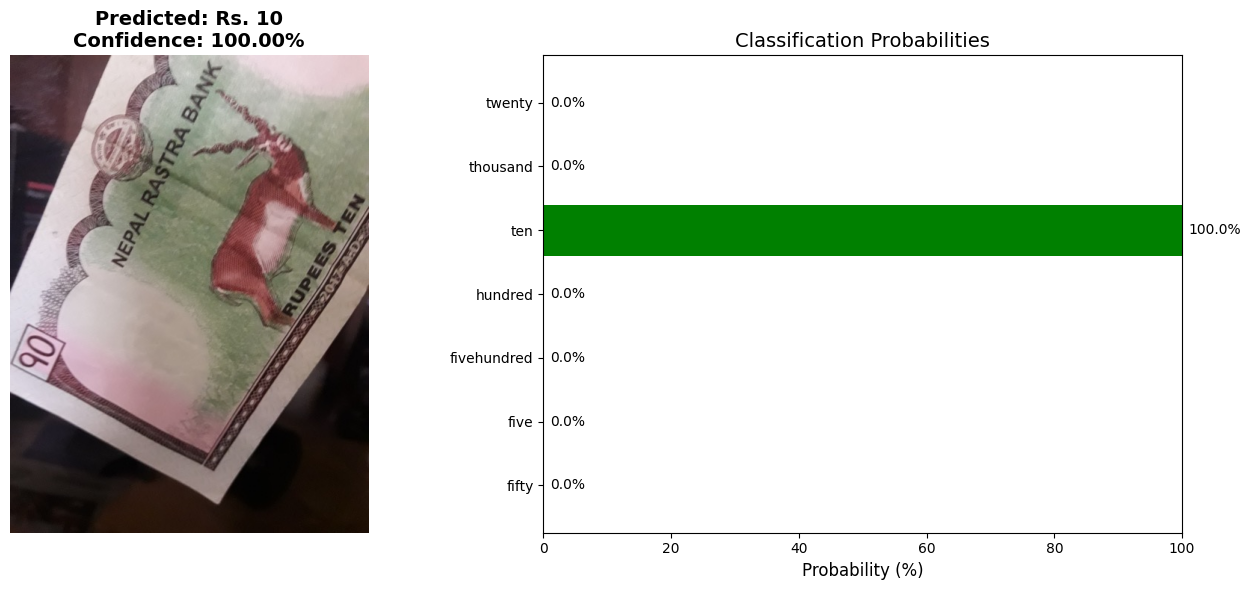


OCR Detected Texts:
  - 8
  - ्ै
  - ई्
  - F
  - प्ै
  - ३

True Class: Rs. 20


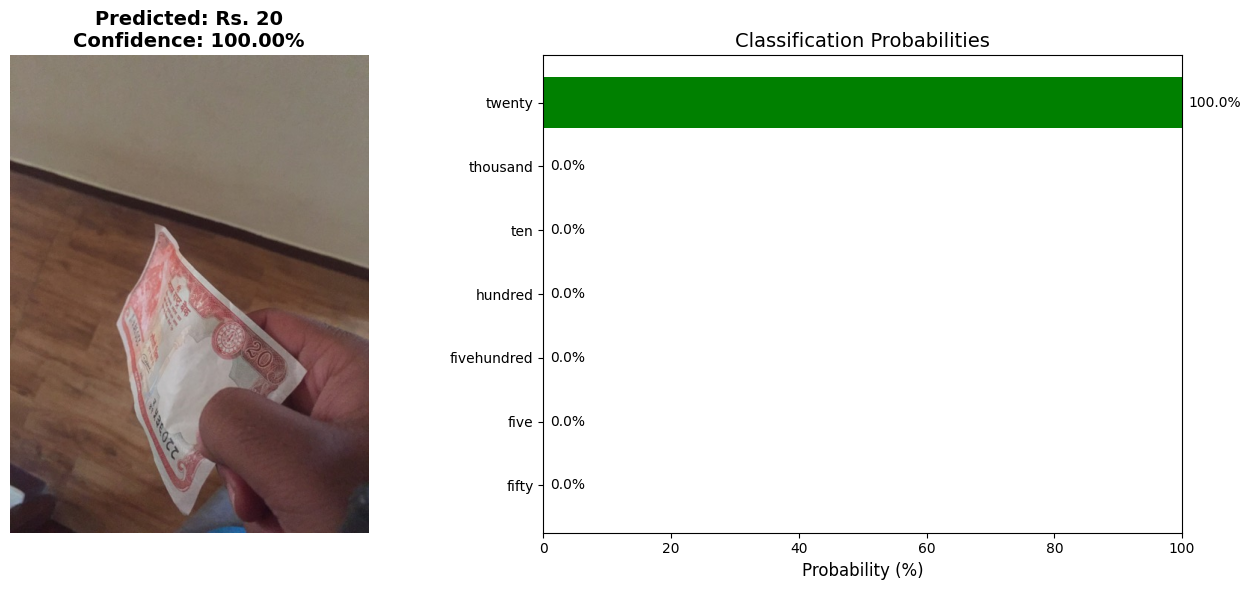


OCR Detected Texts:
  - ६

True Class: Rs. 50


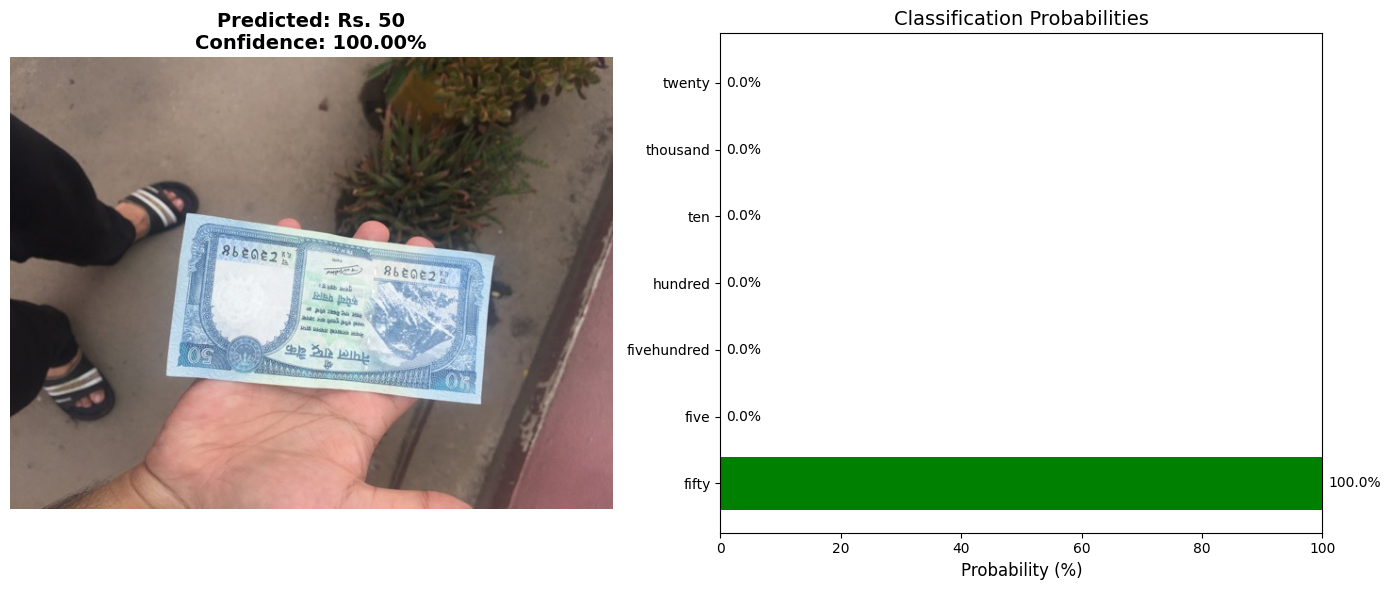


OCR Detected Texts:
  - 8b६०६२ "
  - feleh Ibhe
  - ५k ऊl
  - b६०६२
  - 7+
  - Zlbk

True Class: Rs. 100


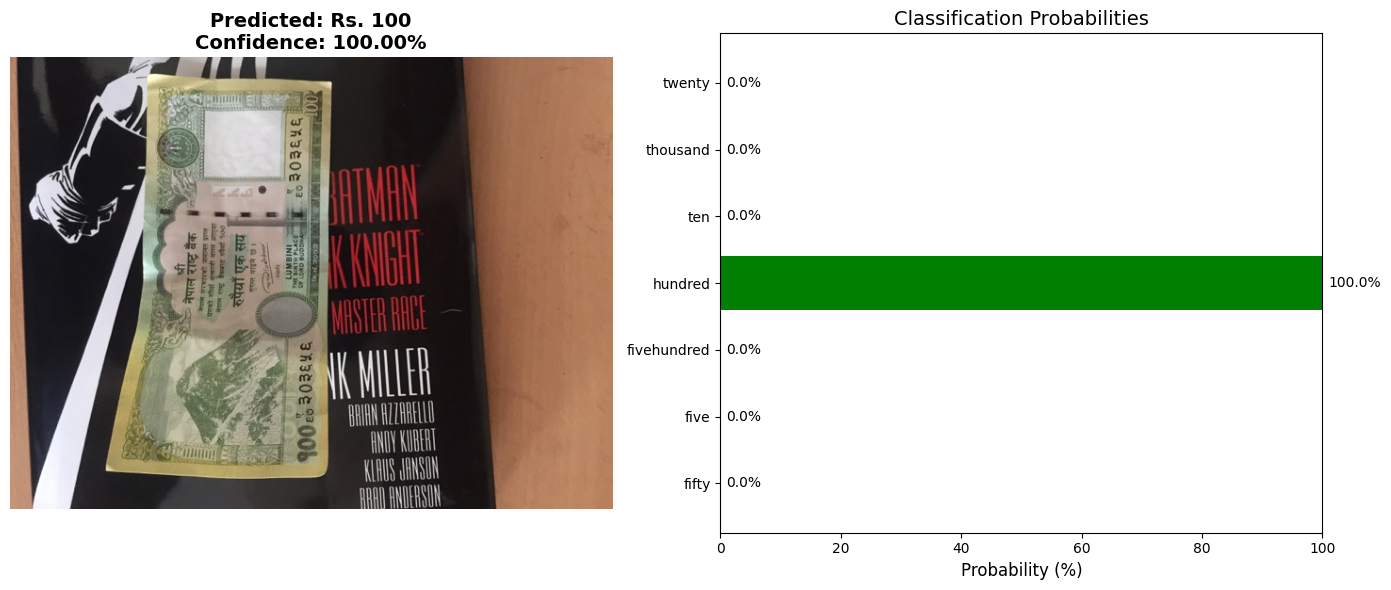


OCR Detected Texts:
  - @
  - IITIIIII
  - ६F१
  - रग ध
  - (IIOIl
  - E
  - M &
  - Fr
  - IIOUJER Rfa[
  - ऐ
  - IILIE१
  - D१III fILIRtIIO
  - 8
  - fIOl IUBCII
  - ILIUQ IIIIOON
  - p०OD CUnCIU|

True Class: Rs. 500


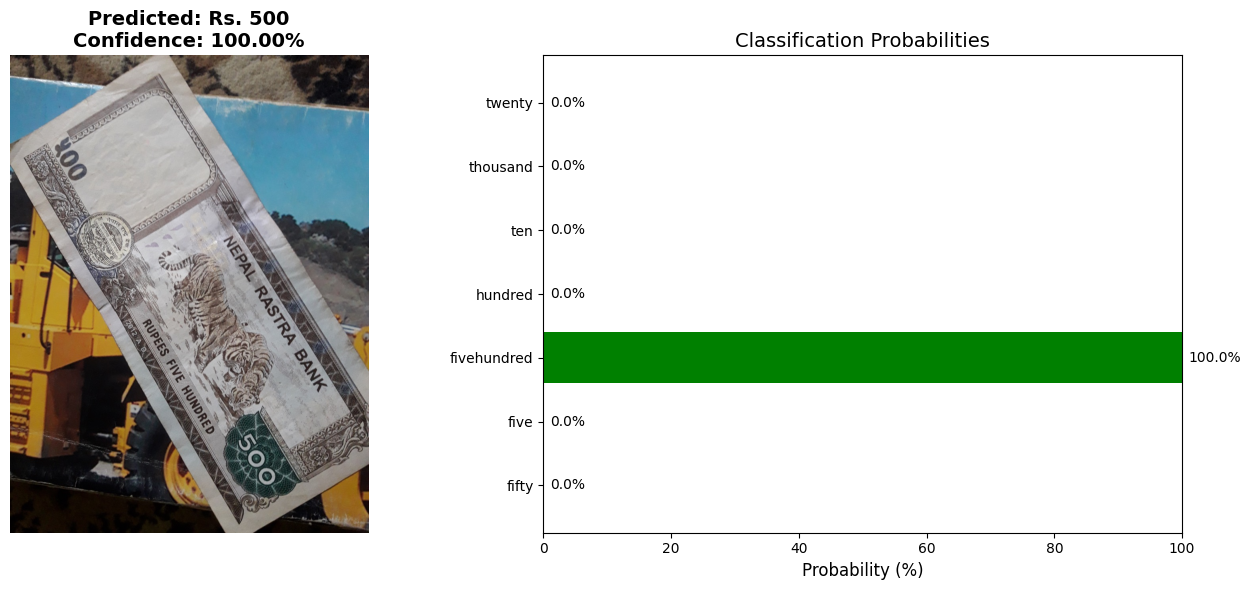


OCR Detected Texts:
  - 0
  - 8
  - ङ्ग
  - ड्रै
  - g
  - ड्लूँ
  - ष्ट्र
  - =्ै
  - ड्डैँ
  - ७

True Class: Rs. 1000


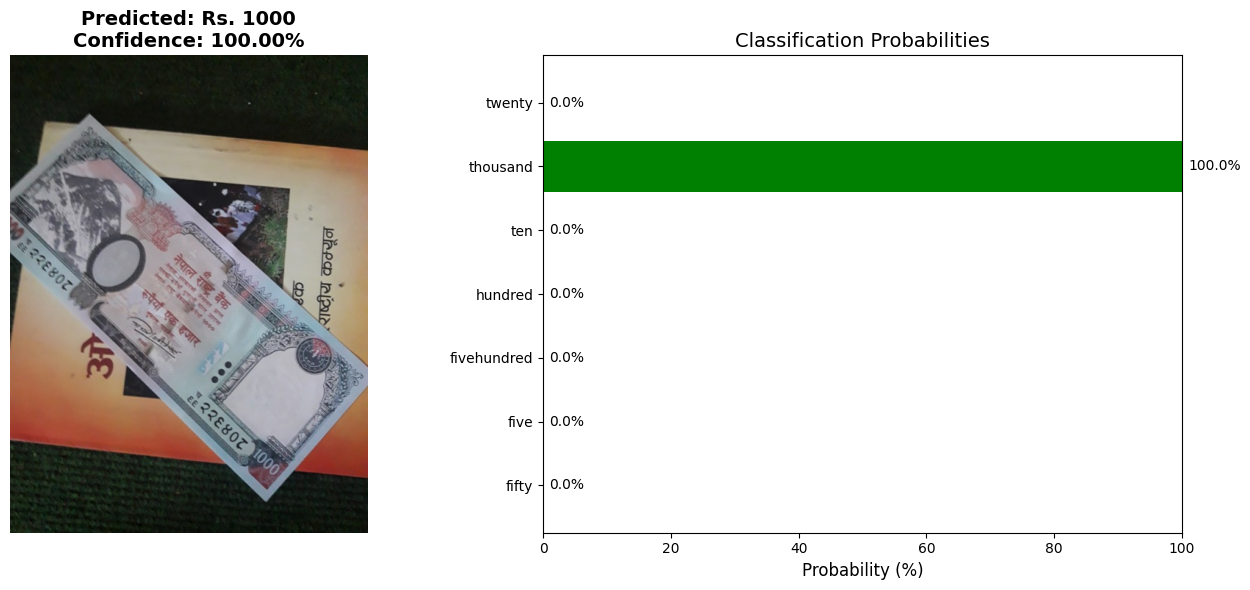


OCR Detected Texts:
  - g
  - g्
  - २२६४०८
  - =
  - &्ै
  - ठठ


In [34]:
# Test on multiple sample images from test set
print("=" * 60)
print("Testing on Sample Images from Test Set")
print("=" * 60)

# Get class names from generator
class_names = list(test_generator.class_indices.keys())

# Get sample images from each class
for class_name in CLASSES:
    class_dir = os.path.join(TEST_DIR, class_name)
    if os.path.exists(class_dir):
        images = os.listdir(class_dir)
        if images:
            # Test on first image of each class
            sample_path = os.path.join(class_dir, images[0])
            print(f"\n{'='*60}")
            print(f"True Class: {class_labels.get(class_name, class_name)}")
            print(f"{'='*60}")
            result = visualize_prediction(sample_path, model, class_names, show_ocr=True)

In [35]:
# Function to predict on a new/custom image
def predict_custom_image(image_path):
    """
    Predict currency denomination for a custom image

    Usage:
        predict_custom_image("path/to/your/currency_image.jpg")
    """
    if not os.path.exists(image_path):
        print(f"Error: Image not found at {image_path}")
        return None

    class_names = list(test_generator.class_indices.keys())
    result = visualize_prediction(image_path, model, class_names, show_ocr=True)

    return result

# Example usage (uncomment and modify path to test with your own image):
# predict_custom_image(r"path\to\your\nepali_currency_image.jpg")

## 9. Load Saved Model and Make Predictions

You can use this section to load the trained model later for inference.

In [36]:
# Load saved model (for later use)
def load_saved_model():
    """Load the saved currency classifier model"""
    model_path = os.path.join(BASE_DIR, 'nepali_currency_classifier.keras')
    best_model_path = os.path.join(BASE_DIR, 'best_currency_model.keras')

    # Try to load best model first, then final model
    if os.path.exists(best_model_path):
        loaded_model = load_model(best_model_path)
        print(f"Loaded best model from: {best_model_path}")
    elif os.path.exists(model_path):
        loaded_model = load_model(model_path)
        print(f"Loaded model from: {model_path}")
    else:
        print("No saved model found. Please train the model first.")
        return None

    return loaded_model

# Class names for inference
CURRENCY_CLASSES = ['fifty', 'five', 'fivehundred', 'hundred', 'ten', 'thousand', 'twenty']

def quick_predict(image_path, loaded_model=None):
    """
    Quick prediction function for inference

    Args:
        image_path: Path to currency image
        loaded_model: Pre-loaded model (optional, will load if not provided)

    Returns:
        Predicted denomination and confidence
    """
    if loaded_model is None:
        loaded_model = load_saved_model()
        if loaded_model is None:
            return None

    # Load and preprocess
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not load image: {image_path}")
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict
    predictions = loaded_model.predict(img, verbose=0)
    pred_idx = np.argmax(predictions[0])
    confidence = predictions[0][pred_idx] * 100

    pred_class = CURRENCY_CLASSES[pred_idx]
    denomination = class_labels.get(pred_class, pred_class)

    print(f"\nPrediction: {denomination}")
    print(f"Confidence: {confidence:.2f}%")

    return denomination, confidence

# Example: Load and test
# loaded_model = load_saved_model()
# quick_predict("path/to/image.jpg", loaded_model)

## Summary

This notebook implements a complete pipeline for **Nepali Currency Detection and Classification**:

### Features:
1. **Data Exploration**: Visualizes dataset distribution and sample images
2. **Data Augmentation**: Applies various transformations to improve model generalization
3. **OCR Detection**: Uses EasyOCR to detect and extract text from currency notes
4. **Deep Learning Classification**: MobileNetV2-based CNN with transfer learning
5. **Two-Phase Training**:
   - Phase 1: Feature extraction with frozen base
   - Phase 2: Fine-tuning with unfrozen layers
6. **Comprehensive Evaluation**: Accuracy, classification report, confusion matrix

### Model Architecture:
- **Base**: MobileNetV2 (pre-trained on ImageNet)
- **Head**: GlobalAveragePooling → BatchNorm → Dense(512) → Dropout → Dense(256) → Softmax

### Currency Classes:
| Class | Denomination |
|-------|--------------|
| five | Rs. 5 |
| ten | Rs. 10 |
| twenty | Rs. 20 |
| fifty | Rs. 50 |
| hundred | Rs. 100 |
| fivehundred | Rs. 500 |
| thousand | Rs. 1000 |

### Files Generated:
- `best_currency_model.keras` - Best model during training
- `nepali_currency_classifier.keras` - Final trained model